# MULTIVARIATE ANALYSIS MODELS

In [ ]:
# Imports
from tabulate import tabulate
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats


# Load data and strip whitespace from column names AND string values
reliability_df = pd.read_csv("../data/cross_split_metrics.csv")

quality_df = pd.read_csv("../data/image_quality_metrics.csv")

infodump_df = pd.read_csv("../data/raw_subject_data.csv")

subjects_df = pd.read_csv("../data/subject.csv")

split_pair_diffs = pd.read_csv("../data/split_comparision_data.csv")

MULTIVARIATE REGRESSION ANALYSIS
Model: Vol_diff ~ GA + SNR_diff + QA_diff + stack_count

Data prepared:
  S1-S2: 23 subjects
  S3-S4: 23 subjects

Table: Regression of SP Volume Diff (S1-S2)
Variable       Coef     SE       t    p-value
-----------  ------  -----  ------  ---------
Intercept    -1.618  1.142  -1.420      0.174
GA            0.076  0.038   1.990      0.063
snr_diff      0.449  0.270   1.660      0.114
qa_diff      -1.411  1.326  -1.060      0.302
stack_count  -0.007  0.035  -0.190      0.852
R-squared            0.284
Adj. R-squared       0.124
N                       23
F-statistic           1.78

Collinearity Statistics (VIF):
  Variable             VIF
  -------------------------
  GA                  8.20 *
  snr_diff            2.71
  qa_diff             2.72
  stack_count         6.38 *

Table: Regression of SP Volume Diff (S3-S4)
Variable       Coef     SE       t  p-value
-----------  ------  -----  ------  ---------
Intercept    -2.955  1.425  -2.070  0.053
GA

NameError: name 'stats' is not defined

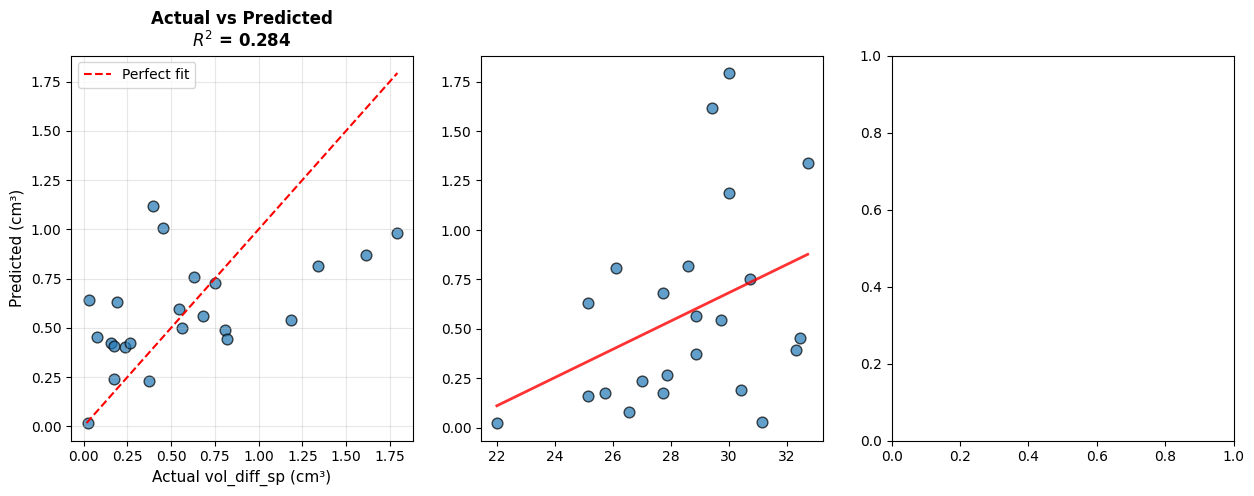

In [ ]:
# Multivariate Analysis - Volume Difference Predictors

# Model: Vol_diff ~ GA + SNR_diff + QA_diff + stack_count
#
# Run 4 models:
#   1. SP, S1-S2
#   2. SP, S3-S4
#   3. CP, S1-S2
#   4. CP, S3-S4
# =============================================================================


import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Load split comparison data (has volume differences already computed)
split_comp_df = pd.read_csv("../data/split_comparision_data.csv")


def prepare_multivariate_data(quality_df, infodump_df, split_comp_df, split_pair):
    """
    Prepare merged dataset for multivariate regression.

    Parameters:
    -----------
    quality_df : pd.DataFrame
        Image quality metrics (SNR per split)
    infodump_df : pd.DataFrame
        Raw subject data (stack_count, QA values)
    split_comp_df : pd.DataFrame
        Split comparison data (volume differences)
    split_pair : str
        'S1-S2' or 'S3-S4'

    Returns:
    --------
    pd.DataFrame with columns: vol_diff_sp, vol_diff_cp, GA, snr_diff, qa_diff, stack_count
    """
    # Filter split comparison data for this pair
    comp_data = split_comp_df[split_comp_df["split_pair"] == split_pair].copy()
    comp_data["subject_id"] = comp_data["subject_id"].astype(str)
    comp_data["session_id"] = comp_data["session_id"].astype(str)

    # Get the two splits
    if split_pair == "S1-S2":
        split1, split2 = "S1", "S2"
        qa_diff_col = "qa_diff_S1S2"
        qa1_col, qa2_col = "QA_S1", "QA_S2"
    else:
        split1, split2 = "S3", "S4"
        qa_diff_col = "qa_diff_S3S4"
        qa1_col, qa2_col = "QA_S3", "QA_S4"

    # Compute SNR differences from quality_df
    quality_df = quality_df.copy()
    quality_df["subject_id"] = quality_df["subject_id"].astype(str)
    quality_df["session_id"] = quality_df["session_id"].astype(str)

    # Get SNR for each split
    snr_s1 = quality_df[quality_df["split"] == split1][
        ["subject_id", "session_id", "snr_subplate", "snr_cortical_plate"]
    ].copy()
    snr_s1 = snr_s1.rename(
        columns={"snr_subplate": "snr_sp_1", "snr_cortical_plate": "snr_cp_1"}
    )

    snr_s2 = quality_df[quality_df["split"] == split2][
        ["subject_id", "session_id", "snr_subplate", "snr_cortical_plate"]
    ].copy()
    snr_s2 = snr_s2.rename(
        columns={"snr_subplate": "snr_sp_2", "snr_cortical_plate": "snr_cp_2"}
    )

    # Merge SNR data
    snr_merged = snr_s1.merge(snr_s2, on=["subject_id", "session_id"], how="inner")
    snr_merged["snr_diff_sp"] = abs(snr_merged["snr_sp_1"] - snr_merged["snr_sp_2"])
    snr_merged["snr_diff_cp"] = abs(snr_merged["snr_cp_1"] - snr_merged["snr_cp_2"])

    # Prepare infodump data
    infodump = infodump_df.copy()
    infodump["subject_id"] = infodump["subject_id"].astype(str)
    infodump["session_id"] = infodump["session_id"].astype(str)

    # Compute QA difference
    infodump[qa_diff_col] = abs(infodump[qa1_col] - infodump[qa2_col])

    # Merge everything
    merged = comp_data.merge(
        snr_merged[["subject_id", "session_id", "snr_diff_sp", "snr_diff_cp"]],
        on=["subject_id", "session_id"],
        how="inner",
    )

    merged = merged.merge(
        infodump[["subject_id", "session_id", "stack_count", qa_diff_col]],
        on=["subject_id", "session_id"],
        how="inner",
    )

    # Rename for clarity
    merged = merged.rename(
        columns={
            "abs_diff_sp": "vol_diff_sp",
            "abs_diff_cp": "vol_diff_cp",
            qa_diff_col: "qa_diff",
        }
    )

    # Convert volume from mm³ to cm³
    merged["vol_diff_sp"] = merged["vol_diff_sp"] / 1000
    merged["vol_diff_cp"] = merged["vol_diff_cp"] / 1000

    return merged


def compute_vif(X):
    """Compute Variance Inflation Factor for each predictor."""
    vif_data = pd.DataFrame()
    vif_data["Variable"] = X.columns
    vif_data["VIF"] = [
        variance_inflation_factor(X.values, i) for i in range(X.shape[1])
    ]
    return vif_data


def run_multivariate_model(df, tissue, split_pair, print_results=True):
    """
    Run OLS regression: vol_diff ~ GA + snr_diff + qa_diff + stack_count
    Returns a dictionary with results and prints a publication-style table.
    """
    # Select appropriate columns
    vol_col = f"vol_diff_{tissue}"
    snr_col = f"snr_diff_{tissue}"

    # Create analysis dataframe
    analysis_df = df[["GA", snr_col, "qa_diff", "stack_count", vol_col]].dropna().copy()
    analysis_df = analysis_df.rename(columns={snr_col: "snr_diff", vol_col: "vol_diff"})

    n = len(analysis_df)

    if n < 10:
        print(f"WARNING: Only {n} complete cases for {tissue.upper()} {split_pair}")
        return None

    # Fit full model
    formula = "vol_diff ~ GA + snr_diff + qa_diff + stack_count"
    model = smf.ols(formula, data=analysis_df).fit()

    # Compute VIF for collinearity check
    X = analysis_df[["GA", "snr_diff", "qa_diff", "stack_count"]]
    vif_df = compute_vif(X)

    if print_results:

        def format_pval(p):
            if p < 0.001:
                return "<0.001 ***"
            if p < 0.01:
                return f"{p:.3f} **"
            if p < 0.05:
                return f"{p:.3f} *"
            return f"{p:.3f}"

        print(f"\n{'='*60}")
        print(f"Table: Regression of {tissue.upper()} Volume Diff ({split_pair})")
        print(f"{'='*60}")

        table_data = []
        for var in model.params.index:
            table_data.append(
                [
                    var,
                    f"{model.params[var]:.3f}",
                    f"{model.bse[var]:.3f}",
                    f"{model.tvalues[var]:.2f}",
                    format_pval(model.pvalues[var]),
                ]
            )

        print(
            tabulate(
                table_data,
                headers=["Variable", "Coef", "SE", "t", "p-value"],
                floatfmt=".3f",
            )
        )

        # Model Fit Statistics Footer
        print(f"{'R-squared':<15} {model.rsquared:>10.3f}")
        print(f"{'Adj. R-squared':<15} {model.rsquared_adj:>10.3f}")
        print(f"{'N':<15} {n:>10}")
        print(f"{'F-statistic':<15} {model.fvalue:>10.2f}")

        print("\nCollinearity Statistics (VIF):")

        # Create a header for the list
        print(f"  {'Variable':<15} {'VIF':>8}")
        print("  " + "-" * 25)

        # Iterate through ALL variables
        for _, row in vif_df.iterrows():
            vif_val = row["VIF"]
            var_name = row["Variable"]

            # Add an asterisk (*) if VIF is high
            highlight = " *" if vif_val > 5 else ""

            print(f"  {var_name:<15} {vif_val:>8.2f}{highlight}")

    return {
        "tissue": tissue,
        "split_pair": split_pair,
        "n": n,
        "model": model,
        "r_squared": model.rsquared,
        "adj_r_squared": model.rsquared_adj,
        "f_stat": model.fvalue,
        "f_pvalue": model.f_pvalue,
        "coefficients": model.params.to_dict(),
        "pvalues": model.pvalues.to_dict(),
        "vif": vif_df,
    }


def compare_models(results_list, variables=None):
    """
    Create comparison table across all 4 models.

    Parameters:
    -----------
    results_list : list
        List of result dictionaries from model runs
    variables : list, optional
        List of variable names to compare. If None, automatically extracts
        from the first valid model's coefficients.
    """
    print(f"\n{'='*80}")
    print("MODEL COMPARISON SUMMARY")
    print(f"{'='*80}")

    # Header
    print(f"\n{'Model':<20} {'N':>5} {'R²':>8} {'Adj R²':>8} {'F':>8} {'F p-val':>10}")
    print(f"{'-'*80}")

    for r in results_list:
        if r is not None:
            label = f"{r['tissue'].upper()} ({r['split_pair']})"
            sig = (
                "***"
                if r["f_pvalue"] < 0.001
                else (
                    "**"
                    if r["f_pvalue"] < 0.01
                    else "*" if r["f_pvalue"] < 0.05 else ""
                )
            )
            print(
                f"{label:<20} {r['n']:>5} {r['r_squared']:>8.4f} {r['adj_r_squared']:>8.4f} {r['f_stat']:>8.2f} {r['f_pvalue']:>9.4f}{sig}"
            )

    # Auto-extract variables from first valid model if not provided
    if variables is None:
        for r in results_list:
            if r is not None and "coefficients" in r:
                variables = list(r["coefficients"].keys())
                break

    if variables is None:
        print("\nNo valid models to compare coefficients.")
        return

    # Coefficient comparison
    print(f"\n{'-'*80}")
    print("COEFFICIENT COMPARISON (significance: * p<0.05, ** p<0.01, *** p<0.001)")
    print(f"{'-'*80}")

    print(f"\n{'Variable':<20}", end="")
    for r in results_list:
        if r is not None:
            label = f"{r['tissue'].upper()}_{r['split_pair'][:2]}"
            print(f"{label:>15}", end="")
    print()
    print(f"{'-'*80}")

    for var in variables:
        print(f"{var:<20}", end="")
        for r in results_list:
            if r is not None:
                coef = r["coefficients"].get(var, np.nan)
                pval = r["pvalues"].get(var, 1.0)
                if np.isnan(coef):
                    print(f"{'N/A':>15}", end="")
                else:
                    sig = (
                        "***"
                        if pval < 0.001
                        else "**" if pval < 0.01 else "*" if pval < 0.05 else ""
                    )
                    print(f"{coef:>12.3f}{sig:>3}", end="")
        print()


def _plot_universal_results(df, tissue, split_pair, model_result, x_axis_col="GA"):
    """
    Universal plotting function for any OLS model.

    Instead of re-predicting (which requires specific column names),
    this extracts the fitted values and residuals directly from the
    statsmodels object and aligns them with the original dataframe
    using the index.

    Parameters:
    -----------
    df : pd.DataFrame
        The dataframe containing the 'GA' column and the target volume column.
    tissue : str
        'sp' or 'cp'
    split_pair : str
        Label for the title (e.g., 'S1-S2')
    model_result : dict
        The dictionary returned by your runner functions (must contain 'model')
    x_axis_col : str
        The main variable to plot against (default 'GA')
    """
    if model_result is None:
        return None

    model = model_result["model"]
    vol_col = f"vol_diff_{tissue}"

    # 1. Get the indices of the data points actually used in the model
    #    (This automatically accounts for rows dropped due to NaNs in ANY predictor)
    valid_indices = model.fittedvalues.index

    # 2. Subset the original dataframe to match the model data
    #    We only strictly need the x_axis_col and the target vol_col here
    plot_data = df.loc[valid_indices].copy()

    # 3. Add model outputs
    plot_data["predicted"] = model.fittedvalues
    plot_data["residuals"] = model.resid
    plot_data["observed"] = plot_data[vol_col]

    # Visual Setup
    tissue_name = "Subplate" if tissue == "sp" else "Cortical Plate"
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # --- Plot 1: Actual vs Predicted ---
    ax1 = axes[0]
    ax1.scatter(
        plot_data["observed"],
        plot_data["predicted"],
        alpha=0.7,
        s=60,
        edgecolors="black",
    )

    # Perfect prediction line
    min_val = min(plot_data["observed"].min(), plot_data["predicted"].min())
    max_val = max(plot_data["observed"].max(), plot_data["predicted"].max())
    ax1.plot([min_val, max_val], [min_val, max_val], "r--", label="Perfect fit")

    ax1.set_xlabel(f"Actual {vol_col} (cm³)", fontsize=11)
    ax1.set_ylabel("Predicted (cm³)", fontsize=11)
    ax1.set_title(
        f"Actual vs Predicted\n$R^2$ = {model.rsquared:.3f}",
        fontsize=12,
        fontweight="bold",
    )
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # --- Plot 2: Volume Diff vs GA (Observed) ---
    ax2 = axes[1]
    ax2.scatter(
        plot_data[x_axis_col],
        plot_data["observed"],
        alpha=0.7,
        s=60,
        edgecolors="black",
        label="Observed Data",
    )

    # Add a simple linear trend line for visualization (Univariate)
    # We use numpy polyfit on the valid data
    if len(plot_data) > 1:
        z = np.polyfit(plot_data[x_axis_col], plot_data["observed"], 1)
        p_line = np.poly1d(z)
        x_range = np.linspace(
            plot_data[x_axis_col].min(), plot_data[x_axis_col].max(), 100
        )
        ax2.plot(
            x_range, p_line(x_range), "r-", linewidth=2, alpha=0.8, label="Linear Trend"
        )

        # Correlation
        r, p = stats.pearsonr(plot_data[x_axis_col], plot_data["observed"])
        corr_label = f"r = {r:.3f}, p = {p:.3f}"
    else:
        corr_label = "Insufficient Data"

    ax2.set_xlabel(f"{x_axis_col} (weeks)", fontsize=11)
    ax2.set_ylabel("Actual Volume Diff (cm³)", fontsize=11)
    ax2.set_title(
        f"Volume Diff vs {x_axis_col}\n{corr_label}", fontsize=12, fontweight="bold"
    )
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # --- Plot 3: Residuals vs GA ---
    ax3 = axes[2]
    ax3.scatter(
        plot_data[x_axis_col],
        plot_data["residuals"],
        alpha=0.7,
        s=60,
        edgecolors="black",
    )
    ax3.axhline(y=0, color="r", linestyle="--", linewidth=2)

    ax3.set_xlabel(f"{x_axis_col} (weeks)", fontsize=11)
    ax3.set_ylabel("Residuals (cm³)", fontsize=11)
    ax3.set_title(f"Residuals vs {x_axis_col}", fontsize=12, fontweight="bold")
    ax3.grid(True, alpha=0.3)

    # --- Super Title ---
    # Try to extract the formula from the result dict if it exists, otherwise generic
    formula_text = model_result.get("formula", "Multivariate Model")

    plt.suptitle(
        f"{tissue_name} - {split_pair}\n{formula_text}",
        fontsize=14,
        fontweight="bold",
        y=1.05,
    )
    plt.tight_layout()

    return fig


# =============================================================================
# RUN ANALYSIS
# =============================================================================

print("=" * 80)
print("MULTIVARIATE REGRESSION ANALYSIS")
print("Model: Vol_diff ~ GA + SNR_diff + QA_diff + stack_count")
print("=" * 80)

# Prepare data for each split pair
data_S1S2 = prepare_multivariate_data(quality_df, infodump_df, split_comp_df, "S1-S2")
data_S3S4 = prepare_multivariate_data(quality_df, infodump_df, split_comp_df, "S3-S4")

print("\nData prepared:")
print(f"  S1-S2: {len(data_S1S2)} subjects")
print(f"  S3-S4: {len(data_S3S4)} subjects")

# Run all 4 models
results = []

# SP S1-S2
results.append(run_multivariate_model(data_S1S2, "sp", "S1-S2"))

# SP S3-S4
results.append(run_multivariate_model(data_S3S4, "sp", "S3-S4"))

# CP S1-S2
results.append(run_multivariate_model(data_S1S2, "cp", "S1-S2"))

# CP S3-S4
results.append(run_multivariate_model(data_S3S4, "cp", "S3-S4"))

# Comparison table
compare_models(results)

# Generate plots
print(f"\n{'='*80}")
print("GENERATING VISUALIZATIONS")
print(f"{'='*80}")

fig1 = _plot_universal_results(data_S1S2, "sp", "S1-S2", results[0])
plt.show()

fig2 = _plot_universal_results(data_S3S4, "sp", "S3-S4", results[1])
plt.show()

fig3 = _plot_universal_results(data_S1S2, "cp", "S1-S2", results[2])
plt.show()

fig4 = _plot_universal_results(data_S3S4, "cp", "S3-S4", results[3])
plt.show()